# 04 - Water Slab Outflux

### Produce water slab outflux grids
This notebook relies on H2O Notebooks 1, 2 and 6 being run beforehand. Slab outflux is defined here as the difference between subducted water and slab storage.

In [1]:
from multiprocessing import Pool, cpu_count
from joblib import Parallel, delayed
import joblib
import numpy as np
import pygplates
import os
os.environ["DISABLE_GPLATELY_DEV_WARNING"] = "true"
import gplately
import gplately.grids as grids
import gplately.tools as tools
import gplately.ptt as ptt
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.io import shapereader as shpreader
import netCDF4
from scipy import ndimage
import pandas as pd
import glob, os
from slabdip import SlabDipper
import numpy.ma as ma
%matplotlib inline
import numpy.ma as ma
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)

from plate_model_manager import PlateModelManager
# plt.style.use('ggplot')

#from pygplates_helper import *

# common variables
extent_globe = [-180, 180, -90, 90]
earth_radius = 6371.0e3
earth_surface_area = 4.0*np.pi*earth_radius**2
tessellation_threshold_radians = np.radians(0.01)

# output grid resolution - should be identical to input grid resolution!
spacingX, spacingY = 0.2, 0.2
resX, resY = int(360./0.2 + 1), int(180./0.2 + 1)
lon_grid = np.arange(extent_globe[0], extent_globe[1]+spacingX, spacingX)
lat_grid = np.arange(extent_globe[2], extent_globe[3]+spacingY, spacingY)
lonq, latq = np.meshgrid(lon_grid,lat_grid)

# reconstruction time steps and spacing
min_time = 0
max_time = 1800
timestep_size = 1

# time array
# reversed (start at min_time, end at max_time)
reconstruction_times = np.arange(min_time, max_time+timestep_size, +timestep_size)




# OUTPUT SAVING TOGGLES
save_output_netcdf = True # !! important
save_output_snapshots = False

save_outputs_to_csv = True

In [2]:
parent_dir = "./Grids/"

# Lithosphere
lithosphere_top_dir = parent_dir+"Reservoirs/Lithosphere/top/"
lithosphere_bottom_dir = parent_dir+ "Reservoirs/Lithosphere/bottom/"

# Crust
crust_bound_dir = parent_dir+"Reservoirs/Crust/bound/"
crust_pore_dir  = parent_dir+"Reservoirs/Crust/pore/"

# Sediments
sediments_bound_dir = parent_dir+"Reservoirs/Sediment/bound/"
sediments_pore_dir = parent_dir+"Reservoirs/Sediment/pore/"


# this relies on a consistent folder structure - don't meddle!

water_components = [lithosphere_bottom_dir, #lithosphere_top_dir,
                    crust_bound_dir, #crust_pore_dir,
                    sediments_bound_dir,] #sediments_pore_dir]
headers  = ['lithosphere_bottom', #'lithosphere_top',
            'crust_bound', #'crust_pore',
            'sediment_bound',] #'sediment_pore',]
            #'mantle', 'crust', 'sediment']
quantities = ["mean"]#["min", "mean", "max"]

output_cdf_filename = "{}/{}/subducted_water_{}_{}.nc"

In [3]:
# Obtain all rotation files, topology features and static polygons from Muller et al. 2019
pm_manager = PlateModelManager()
muller2025_model = pm_manager.get_model("Muller2025", data_dir="plate-model-repo")
rotation_model = muller2025_model.get_rotation_model()
topology_features = muller2025_model.get_topologies()
static_polygons = muller2025_model.get_static_polygons()

model = gplately.PlateReconstruction(rotation_model, topology_features, static_polygons)

# Obtain geometry shapefiles with gdownload
coastlines = muller2025_model.get_coastlines()
continents = muller2025_model.get_continental_polygons()
COBs = muller2025_model.get_COBs()

# Call the PlotTopologies object
time = 50 #Ma
gplot = gplately.PlotTopologies(model, coastlines=coastlines, continents=continents, COBs=COBs, time=time)

In [4]:
cell_area = tools.lat_area_function(lat_grid, lat_grid+spacingY, lon_grid.size)
cell_area = np.tile(cell_area.reshape(-1,1), lon_grid.size)

In [5]:
# Define water quantities
quantities = ["min", "mean", "max"]

# Define path to the subducted water contributions per timestep
def get_subducted_water_grid_filename(c, quantity, reconstruction_time):
    subducted_water_grid_filename = water_components[c]+"{}/subducted_water_{}_{}.nc".format(
        quantity, headers[c].split('_')[0], reconstruction_time
    )
    return subducted_water_grid_filename

def get_stored_water_grid_filename(c, quantity, reconstruction_time):
    stored_water_grid_filename = water_components[c]+"{}/stored_water_{}_{}.nc".format(
        quantity, headers[c].split('_')[0], reconstruction_time
    )
    return stored_water_grid_filename


os.makedirs(parent_dir+"/smoothed_slab_outflux/", exist_ok=True)

In [7]:

import sys
sys.path.insert(0, '../utils/')

import fft_gaussian_filter as fft_gaussian_filter_script

def gaussian_smooth_grid(data, distance_km):

    """ Smooth grids using a Gaussian. 
    If input grid comes with a mask, all masked values are retained. 
    """
    mask = np.isnan(data)
    smoothed_grid = fft_gaussian_filter_script.fft_gaussian_filter(data, distance_km)
    smoothed_grid[mask] = np.nan
    return smoothed_grid

In [8]:
save_smoothed_timestep_grid = False

def produce_slab_outflux_grid(c, component, reconstruction_time, distance_km=300):
    """Function to read water contribution plots for the given component and time, 
    smooth it, then return the smoothed piecewise grid. 
    """
    
    # Store cumulative subducted water from the grids in a numpy array
    slab_outflux_components = np.zeros((3, resY, resX))
    smoothed_slab_outflux_components = np.zeros((3, resY, resX))

    for i, quantity in enumerate(quantities):

        outflux_grid_filename = water_components[c]+"{}/slab_outflux_water_{}_{}.nc".format(
            quantity, headers[c].split('_')[0], reconstruction_time
        )
        if save_smoothed_timestep_grid:
            smoothed_filename = parent_dir+"/smoothed_slab_outflux/{}km/{}/{}/".format(distance_km, headers[c], quantity)
            os.makedirs(smoothed_filename, exist_ok=True)
            
        # Read the masked subducted water and water storage contribution array for the current time
        subducted_water_filename = get_subducted_water_grid_filename(c, quantity, reconstruction_time)
        current_subduction_grid = grids.read_netcdf_grid(subducted_water_filename)
        #print(current_subduction_grid)
        stored_water_filename = get_stored_water_grid_filename(c, quantity, reconstruction_time)
        current_storage_grid = grids.read_netcdf_grid(stored_water_filename)
        
        # Get the data array, and fill all NaNs with 0s.
        current_subduction_grid = np.nan_to_num(current_subduction_grid.data)
        current_subduction_grid_filled = grids.fill_raster(current_subduction_grid)
        current_storage_grid = np.nan_to_num(current_storage_grid.data)
        current_storage_grid_filled = grids.fill_raster(current_storage_grid)

        current_slab_outflux_grid_filled = current_subduction_grid_filled - current_storage_grid_filled
        
        slab_outflux_components[i] = current_slab_outflux_grid_filled

        current_time_grid_filled_masked = ma.masked_array(current_slab_outflux_grid_filled)
        current_time_grid_filled_masked = ma.masked_values(current_time_grid_filled_masked, 0.0)
        current_time_grid_filled_masked.fill_value = np.nan
        
        slab_outflux_grid_to_save = np.ma.array(
            slab_outflux_components[i],
            mask = current_time_grid_filled_masked.mask,
            fill_value=np.nan
        )

        grids.write_netcdf_grid(
                outflux_grid_filename,
                slab_outflux_grid_to_save
            )

        # If the user wants the smoothed piecewise grids to be returned,
        if save_smoothed_timestep_grid:

            # Smooth the grids
            smoothed_current_time_grid = gaussian_smooth_grid(
                current_slab_outflux_grid_filled,
                distance_km=distance_km
            )
            # Read in the smoothed grid, fill the raster, and return
            smoothed_current_time_grid_filled = grids.fill_raster(smoothed_current_time_grid)
            smoothed_slab_outflux_components[i] += smoothed_current_time_grid_filled
            
            # Create a mask for the interpolated grid - all values with 0s need to have an equivalent
            # mask value of NaN. 
            smoothed_current_time_grid_filled_masked = ma.masked_array(smoothed_current_time_grid_filled)
            smoothed_current_time_grid_filled_masked = ma.masked_values(smoothed_current_time_grid_filled_masked, 0.0)
            smoothed_current_time_grid_filled_masked.fill_value = np.nan
            
            current_slab_outflux_smoothed = np.ma.array(
                    smoothed_slab_outflux_components[i],
                    mask = smoothed_current_time_grid_filled_masked.mask,
                    fill_value=np.nan
                )
            
            grids.write_netcdf_grid(
                smoothed_filename+"/slab_outflux_{}_{}.nc".format(headers[c], reconstruction_time),
                current_slab_outflux_smoothed
            )

    return np.sum(slab_outflux_components[0]), np.sum(slab_outflux_components[1]), np.sum(slab_outflux_components[2])

In [9]:
time_splitter_integer = -5

In [10]:
with Parallel(n_jobs=-3, verbose=1) as parallel:

    slab_outflux_timeseries = np.zeros((len(headers), len(reconstruction_times), 3))
    
    # Split the time array into groups of timesteps
    split_times = np.array_split(reconstruction_times, cpu_count() - time_splitter_integer)
    
    # Loop through each time array. get a group of subducted water contributions
    for times in split_times:
        for c, component in enumerate(headers):
            
            print("Building slab outflux {} grids from {} to {}Ma...".format(component, times[0], times[-1]))

            # Read the timewise contributions from this batch of times and smooth them. 
            results = parallel(delayed(produce_slab_outflux_grid)(
                c,
                component, 
                time,
                distance_km=500
            ) 
               for time in times
            )
            slab_outflux_timeseries[c,times,:] = np.array(results)

Building slab outflux lithosphere_bottom grids from 0 to 120Ma...


[Parallel(n_jobs=-3)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-3)]: Done  34 tasks      | elapsed:    9.2s
[Parallel(n_jobs=-3)]: Done 121 out of 121 | elapsed:   21.9s finished
[Parallel(n_jobs=-3)]: Using backend LokyBackend with 8 concurrent workers.


Building slab outflux crust_bound grids from 0 to 120Ma...


[Parallel(n_jobs=-3)]: Done  34 tasks      | elapsed:    5.9s
[Parallel(n_jobs=-3)]: Done 121 out of 121 | elapsed:   18.3s finished
[Parallel(n_jobs=-3)]: Using backend LokyBackend with 8 concurrent workers.


Building slab outflux sediment_bound grids from 0 to 120Ma...


...

[Parallel(n_jobs=-3)]: Done  34 tasks      | elapsed:    7.2s
[Parallel(n_jobs=-3)]: Done 120 out of 120 | elapsed:   19.4s finished
[Parallel(n_jobs=-3)]: Using backend LokyBackend with 8 concurrent workers.


Building slab outflux crust_bound grids from 1681 to 1800Ma...


[Parallel(n_jobs=-3)]: Done  34 tasks      | elapsed:    7.5s
[Parallel(n_jobs=-3)]: Done 120 out of 120 | elapsed:   19.5s finished
[Parallel(n_jobs=-3)]: Using backend LokyBackend with 8 concurrent workers.


Building slab outflux sediment_bound grids from 1681 to 1800Ma...


[Parallel(n_jobs=-3)]: Done  34 tasks      | elapsed:    7.0s
[Parallel(n_jobs=-3)]: Done 120 out of 120 | elapsed:   19.9s finished


In [11]:
import scipy.ndimage as sn

# This works for smoothing arrays with a (4,1000,3) shape.
def median_filter_3d(array, time_window):
    smooth_result = np.zeros_like(array)
    for c in range(array.shape[0]):
        for i in range(3):
            smooth_result[c,:,i] = sn.median_filter(array[c,:,i], size=time_window)
            
    return smooth_result

# This works for smoothing arrays with a 2D, i.e. (1000,3) shape.
def median_filter_2d(array, time_window):
    smooth_result = np.zeros_like(array)
    for i in range(array.shape[-1]):
        smooth_result[:,i] = sn.median_filter(array[:,i], size=time_window)
    
    return smooth_result

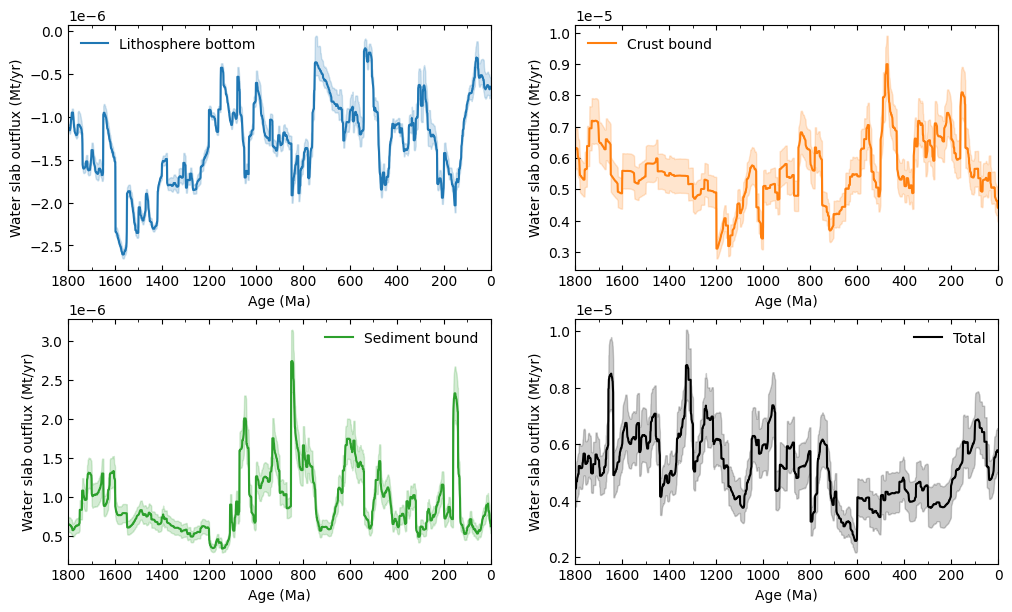

In [22]:
# compare each contribution (separate axes)
time_window = 10

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2,2, figsize=(12,7))

for c, ax in enumerate([ax1,ax2,ax3,ax4]):

    if c <3:
        
        label = headers[c].replace('_', ' ')
        label = label.capitalize()
    
        ax.fill_between(reconstruction_times[::-1],
                        sn.median_filter(slab_outflux_timeseries[c,:,0][::-1]*1e-6, size=time_window),
                        sn.median_filter(slab_outflux_timeseries[c,:,2][::-1]*1e-6, size=time_window),
                        color='C{}'.format(c), alpha=0.2)
        ax.plot(reconstruction_times[::-1], sn.median_filter(slab_outflux_timeseries[c,:,1][::-1]*1e-6, size=time_window), c="C{}".format(c), label=label)
    else:
        label = "Total"
        label = label.capitalize()
        
        ax.fill_between(reconstruction_times[::-1],
                        sn.median_filter(np.sum(slab_outflux_timeseries[:,:,0][::-1]*1e-6, axis=0), size=time_window),
                        sn.median_filter(np.sum(slab_outflux_timeseries[:,:,2][::-1]*1e-6, axis=0), size=time_window),
                        color='k', alpha=0.2)
        ax.plot(reconstruction_times[::-1], sn.median_filter(np.sum(slab_outflux_timeseries[:,:,1][::-1]*1e-6, axis=0), size=time_window), c="k", label=label)


    ax.xaxis.set_minor_locator(MultipleLocator(100))
    ax.tick_params(axis="both", direction="in", which="both", right=False, top=True)
    ax.set_xlim(max_time,min_time)
    ax.set_xlabel('Age (Ma)')
    ax.set_ylabel('Water slab outflux (Mt/yr)')
    ax.legend(frameon=False)

#fig.savefig(figure_dir+"/water_subducted_comparison.pdf", bbox_inches='tight', dpi=300)
#fig.savefig(figure_dir+"/water_subducted_comparison.svg", bbox_inches='tight', dpi=300)
#fig.savefig(figure_dir+"/water_subducted_comparison.png", bbox_inches='tight', dpi=300)